In [1]:
import re
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:

def summarize_timing_log(timing_text_string,
                        pattern = r'^\s*(\d+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)'
                        ):
    time_summary = []
    with open(timing_text_string, 'r') as file:
        for line_number, line in enumerate(file, start=1):
            match = re.match(pattern, line)
            if match:
                run_id, elapsed, user_gpu, sys_gpu = match.groups()
                time_summary.append({
                    "Run_ID": int(run_id),
                    "Elapsed": float(elapsed),
                    "User_CPU": float(user_gpu),
                    "Sys_CPU": float(sys_gpu),
                    "Line": line_number,  # optional: track line number
                })

    return time_summary

# Regular expression pattern to capture the number before "seconds"


def output_times_for_each_subprocesses(timing_text_string, pattern = r"([\d.]+)\s+seconds"):

    seconds_for_each_process = []


    with open(timing_text_string, 'r') as file:
        for line_number, line in enumerate(file, start=1):
            match = re.search(pattern, line)  # use search, not match, since the number may not be at the start
            if match:
                
                seconds = float(match.group(1))
                seconds_for_each_process.append(seconds)
                # print(f"Line {line_number}\n line {line}\n: {seconds} seconds\n\n")

    time_for_reading_Bragg_disk_list = seconds_for_each_process[1]
    time_for_changing_coordinate_and_making_tensor = seconds_for_each_process[2]
    time_for_model_prediction = seconds_for_each_process[3] + seconds_for_each_process[4]
    time_for_making_orientation_map_from_prediction = seconds_for_each_process[5]

    time_for_processes_refined = []
    time_for_processes_refined.append(time_for_reading_Bragg_disk_list)
    time_for_processes_refined.append(time_for_changing_coordinate_and_making_tensor)
    time_for_processes_refined.append(time_for_model_prediction)
    time_for_processes_refined.append(time_for_making_orientation_map_from_prediction)
    

    return np.array(time_for_processes_refined)


In [3]:
script_path = os.getcwd() + "/"

processed_data_loading_path = script_path + "compute_Time_summary/"

fig03_panel_a_e_path = script_path + "panel_a_e/"


In [4]:


scan_dimensions = []
numb_diffPattern = []
for i in range(3,11):
    scan_dimensions.append(int(2**i))
    numb_diffPattern.append(int((2**i)**2))
    
scan_dimensions = np.array(scan_dimensions)
numb_diffPattern = np.array(numb_diffPattern)

print("scan dimensions used in this study:\n", scan_dimensions, "\n")
print("number of diffraction patterns for each data:\n", numb_diffPattern, "\n")


scan dimensions used in this study:
 [   8   16   32   64  128  256  512 1024] 

number of diffraction patterns for each data:
 [     64     256    1024    4096   16384   65536  262144 1048576] 



## Figure 3 panel d

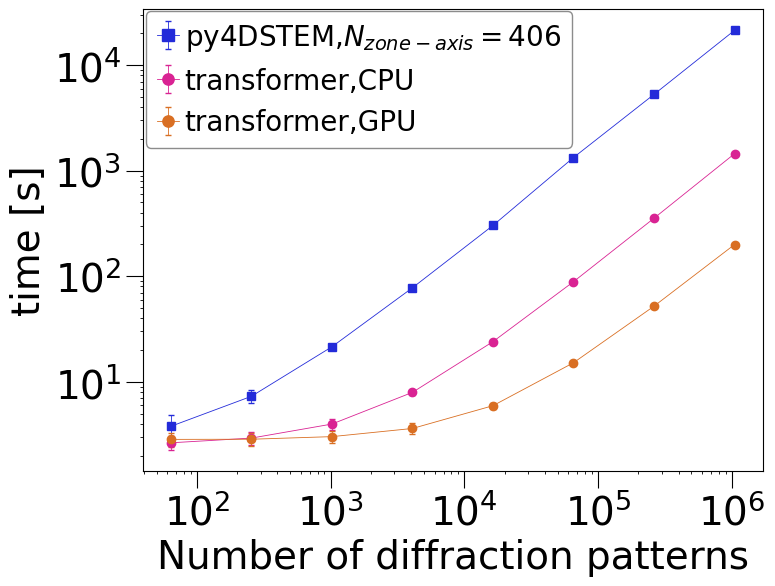

In [5]:

py4DSTEM_total_time_average = []
py4DSTEM_total_time_std = []
py4DSTEM_total_coefficient_of_variation = []
CPU_total_time_average = []
CPU_total_time_std = []
CPU_total_coefficient_of_variation = []
GPU_total_time_average = []
GPU_total_time_std = []
GPU_total_coefficient_of_variation = []

for scan_dim in scan_dimensions:
    py4DSTEM_dir = processed_data_loading_path + "timing_log_SD%d_ZADP2_ID1-10_py4DSTEM/"%(scan_dim)
    CPU_dir = processed_data_loading_path + "timing_log_SD%d_ID1-10_CPU/"%(scan_dim)
    GPU_dir = processed_data_loading_path + "timing_log_SD%d_ID1-10_GPU/"%(scan_dim)


    py4DSTEM_summary = summarize_timing_log(py4DSTEM_dir + "summary.txt")
    py4DSTEM_wall_time = np.array([entry['Elapsed'] for entry in py4DSTEM_summary])

    py4DSTEM_mean_time = np.mean(py4DSTEM_wall_time)
    py4DSTEM_std_time = np.std(py4DSTEM_wall_time, ddof=1)
    py4DSTEM_cv = (py4DSTEM_std_time / py4DSTEM_mean_time)

    py4DSTEM_total_time_average.append(py4DSTEM_mean_time)
    py4DSTEM_total_time_std.append(py4DSTEM_std_time)
    py4DSTEM_total_coefficient_of_variation.append(py4DSTEM_cv)


    CPU_summary = summarize_timing_log(CPU_dir + "summary.txt")
    CPU_wall_time = np.array([entry['Elapsed'] for entry in CPU_summary])

    CPU_mean_time = np.mean(CPU_wall_time)
    CPU_std_time = np.std(CPU_wall_time, ddof=1)
    CPU_cv = (CPU_std_time / CPU_mean_time)

    CPU_total_time_average.append(CPU_mean_time)
    CPU_total_time_std.append(CPU_std_time)
    CPU_total_coefficient_of_variation.append(CPU_cv)

    GPU_summary = summarize_timing_log(GPU_dir + "summary.txt")
    GPU_wall_time = np.array([entry['Elapsed'] for entry in GPU_summary])

    GPU_mean_time = np.mean(GPU_wall_time)
    GPU_std_time = np.std(GPU_wall_time, ddof=1)
    GPU_cv = (GPU_std_time / GPU_mean_time)

    GPU_total_time_average.append(GPU_mean_time)
    GPU_total_time_std.append(GPU_std_time)
    GPU_total_coefficient_of_variation.append(GPU_cv)

py4DSTEM_total_time_average = np.array(py4DSTEM_total_time_average)
py4DSTEM_total_time_std = np.array(py4DSTEM_total_time_std)
py4DSTEM_total_coefficient_of_variation = np.array(py4DSTEM_total_coefficient_of_variation)

CPU_total_time_average = np.array(CPU_total_time_average)
CPU_total_time_std = np.array(CPU_total_time_std)
CPU_total_coefficient_of_variation = np.array(CPU_total_coefficient_of_variation)

GPU_total_time_average = np.array(GPU_total_time_average)
GPU_total_time_std = np.array(GPU_total_time_std)
GPU_total_coefficient_of_variation = np.array(GPU_total_coefficient_of_variation)


fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.errorbar(
    x = numb_diffPattern, 
    y = py4DSTEM_total_time_average, 
    yerr = py4DSTEM_total_time_std, 
    marker = 's', 
    label = r"py4DSTEM,$N_{zone-axis}=406$", 
    markersize = 6, 
    linewidth = 0.6, 
    capsize=2,
    color = "#232BD9",
)
ax.errorbar(
    x = numb_diffPattern, 
    y = CPU_total_time_average, 
    yerr = CPU_total_time_std, 
    marker = 'o', 
    label = r"transformer,CPU", 
    markersize = 6, 
    linewidth = 0.6,
    capsize=2,
    color = "#D92393",
)
ax.errorbar(
    x = numb_diffPattern, 
    y = GPU_total_time_average, 
    yerr = GPU_total_time_std, 
    marker = 'o', 
    label = r"transformer,GPU", 
    markersize = 6, 
    linewidth = 0.6,
    capsize=2,
    color = "#D96F23",
)

ax.legend(
    loc=(0.005,0.7),          # automatic placement
    fontsize=20,         # legend text size
    frameon=True,        # draw a box around the legend
    framealpha=0.9,      # transparency of the box
    edgecolor='gray',    # legend box border color
    handlelength=0.8,      # length of the line in legend
    handletextpad=0.2,
    markerscale=1.35,
)
ax.set_xlabel(r"Number of diffraction patterns", fontsize = 28)
ax.set_ylabel(r"time [s]", fontsize = 28)
ax.set_yscale('log')
ax.set_xscale('log')
ax.tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=28)
ax.tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=28)
plt.savefig(fig03_panel_a_e_path + "time_for_orientation_mapping.pdf", bbox_inches='tight', dpi = 300)
plt.show()

## Figure 3 panel e

average_times_for_process_in_current_dimension
 [0.0192582 0.0032856 0.2698588 0.003612 ]
std_times_for_process_in_current_dimensio
 [7.13053964e-04 8.22587003e-04 3.08126853e-02 3.56869101e-05] 

average_times_for_process_in_current_dimension
 [0.0319281 0.0102307 0.2753897 0.0146435]
std_times_for_process_in_current_dimensio
 [6.74584226e-04 8.25087342e-04 2.84491079e-02 4.88972846e-05] 

average_times_for_process_in_current_dimension
 [0.0818192 0.0369011 0.3135532 0.0403853]
std_times_for_process_in_current_dimensio
 [0.00152274 0.00116707 0.02873238 0.00126123] 

average_times_for_process_in_current_dimension
 [0.3553353 0.135739  0.4533004 0.1204496]
std_times_for_process_in_current_dimensio
 [0.00564172 0.00560895 0.02800165 0.00213082] 

average_times_for_process_in_current_dimension
 [1.1489951 0.7161266 1.09295   0.4297004]
std_times_for_process_in_current_dimensio
 [0.01602982 0.02277216 0.03252735 0.00626351] 

average_times_for_process_in_current_dimension
 [4.524805  2.71

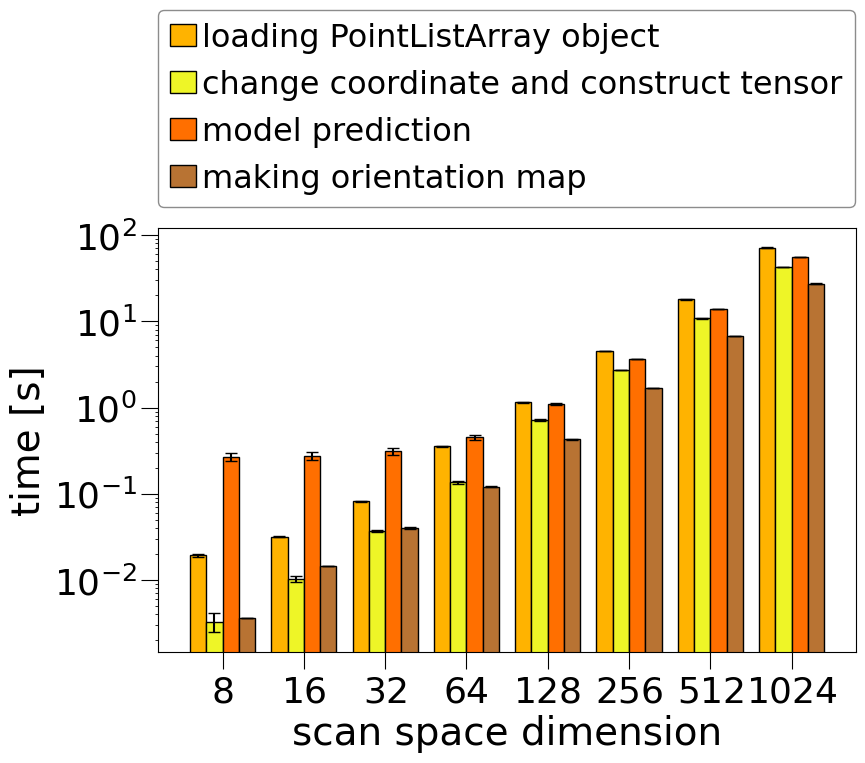

In [6]:



total_time_averages_for_subprocess = []
total_std_for_subprocess = []

for scan_dim in scan_dimensions:
    times_for_process_in_current_dimension = []
    
    for ID in range(1,11):
        GPU_dir = processed_data_loading_path + "timing_log_SD%d_ID1-10_GPU/"%(scan_dim)

        times_for_process_in_current_dimension.append(output_times_for_each_subprocesses(GPU_dir + "output_SD%d_ID%d.log"%(scan_dim, ID)))

    times_for_process_in_current_dimension = np.array(times_for_process_in_current_dimension)

    average_times_for_process_in_current_dimension = np.average(times_for_process_in_current_dimension, axis = 0)
    std_times_for_process_in_current_dimension = np.std(times_for_process_in_current_dimension, axis = 0, ddof = 1)

    print("average_times_for_process_in_current_dimension\n", average_times_for_process_in_current_dimension)
    print("std_times_for_process_in_current_dimensio\n", std_times_for_process_in_current_dimension, "\n")



    total_time_averages_for_subprocess.append(average_times_for_process_in_current_dimension)
    total_std_for_subprocess.append(std_times_for_process_in_current_dimension)



total_time_averages_for_subprocess = np.array(total_time_averages_for_subprocess)
total_std_for_subprocess = np.array(total_std_for_subprocess)



bar_width = 0.2
# Create the figure and axis
fig, ax = plt.subplots(figsize=(9, 5.5))

labels = ["loading PointListArray object", "change coordinate and construct tensor", "model prediction", "making orientation map"]
colors = ['#FFB300', '#EEF527', '#FF6F00', '#B87333']
n_datasets, n_timesteps = total_time_averages_for_subprocess.shape

print("n_datasets", n_datasets)
print("n_timesteps", n_timesteps, "\n")

x = np.arange(n_datasets)

print("x\n", x, "\n")

for i in range(n_timesteps):
    ax.bar(
        x + i * bar_width,  # Shift each timestep’s bars
        total_time_averages_for_subprocess[:, i],
        yerr=total_std_for_subprocess[:, i],  # Add standard deviation as error bars
        width=bar_width,
        color = colors[i],
        capsize=4,  # small horizontal line on error bars
        label=labels[i],
        edgecolor='black',  # Black edge for each bar
    )

# Labeling
ax.set_xlabel('scan space dimension',fontsize = 28)
ax.set_ylabel('time [s]',fontsize = 28)
ax.set_yscale('log')
ax.set_xticks(x + bar_width * (n_timesteps - 1) / 2)

power_for_tick_labels = []

for i in range(n_datasets):
    power_for_tick_labels.append(int(2**(i+3)))



ax.set_xticklabels([r"$%d$" % i for i in power_for_tick_labels])

ax.legend(
    loc=(-0.001,1.05),          # automatic placement
    fontsize=23,         # legend text size
    frameon=True,        # draw a box around the legend
    framealpha=0.9,      # transparency of the box
    edgecolor='gray',    # legend box border color
    handlelength=0.8,      # length of the line in legend
    handletextpad=0.2,
    markerscale=1.35,
)
ax.tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=26, pad = 5.1)
ax.tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=26)
# plt.savefig(fig03_panel_a_e_path + "time_for_subprocesses_GPU.pdf", bbox_inches='tight', dpi = 300)

plt.show()


### Table S2 py4DSTEM computation time log summary.

In [9]:

stack_0008_0064 = []
stack_0128_1024 = []
for scan_dim in scan_dimensions:
    py4DSTEM_dir = processed_data_loading_path + "timing_log_SD%d_ZADP2_ID1-10_py4DSTEM/"%(scan_dim)

    py4DSTEM_summary = summarize_timing_log(py4DSTEM_dir + "summary.txt")
    py4DSTEM_wall_time = np.array([entry['Elapsed'] for entry in py4DSTEM_summary])
    py4DSTEM_userCPU_time = np.array([entry['User_CPU'] for entry in py4DSTEM_summary])
    py4DSTEM_sysCPU_time = np.array([entry['Sys_CPU'] for entry in py4DSTEM_summary])

    py4DSTEM_mean_time = np.mean(py4DSTEM_wall_time)
    py4DSTEM_std_time = np.std(py4DSTEM_wall_time, ddof=1)
    py4DSTEM_cv = (py4DSTEM_std_time / py4DSTEM_mean_time)

    # py4DSTEM_total_time_average.append(py4DSTEM_mean_time)
    # py4DSTEM_total_time_std.append(py4DSTEM_std_time)
    # py4DSTEM_total_coefficient_of_variation.append(py4DSTEM_cv)

    print("")
    print("scan_dim", scan_dim, "\n")

    time_stack = []

    # print("py4DSTEM_summary\n", py4DSTEM_summary, "\n")
    # print("py4DSTEM_wall_time", py4DSTEM_wall_time)
    # print("py4DSTEM_userCPU_time", py4DSTEM_userCPU_time)
    # print("py4DSTEM_sysCPU_time", py4DSTEM_sysCPU_time)

    time_stack.append(py4DSTEM_wall_time)
    time_stack.append(py4DSTEM_userCPU_time)
    time_stack.append(py4DSTEM_sysCPU_time)
    time_stack = np.array(time_stack)
    time_stack = time_stack.T
    print("time_stack\n", time_stack, "\n")

    if scan_dim < 65:
        stack_0008_0064.append(time_stack)
    else:
        stack_0128_1024.append(time_stack)

stack_0008_0064 = np.hstack(stack_0008_0064)
stack_0128_1024 = np.hstack(stack_0128_1024)

print("")
print("#############################")
print("stack_0008_0064\n", stack_0008_0064, "\n")

latex = np.array2string(
    stack_0008_0064,
    separator=' & ',
    max_line_width=10**6,
    formatter={'float_kind': lambda x: f"{x:.2f}"}
)

latex = latex.replace('[', '').replace(']', '')
latex = latex.replace('\n', ' \\\\\n')

print(latex)

print("")
print("#############################")
print("stack_0128_1024\n", stack_0128_1024, "\n")

latex = np.array2string(
    stack_0128_1024,
    separator=' & ',
    max_line_width=10**6,
    formatter={'float_kind': lambda x: f"{x:.2f}"}
)

latex = latex.replace('[', '').replace(']', '')
latex = latex.replace('\n', ' \\\\\n')

print(latex)


scan_dim 8 

time_stack
 [[6.79 9.99 1.16]
 [3.46 8.06 0.53]
 [3.48 8.1  0.5 ]
 [3.28 7.9  0.51]
 [3.51 8.13 0.49]
 [3.32 7.97 0.47]
 [3.55 8.16 0.52]
 [3.44 8.06 0.5 ]
 [3.43 8.06 0.51]
 [3.56 8.19 0.5 ]] 


scan_dim 16 

time_stack
 [[10.12 12.78  1.7 ]
 [ 7.2  11.24  1.08]
 [ 7.12 11.1   1.14]
 [ 7.04 11.07  1.09]
 [ 6.87 10.9   1.1 ]
 [ 6.79 10.87  1.05]
 [ 6.99 11.05  1.07]
 [ 7.02 11.07  1.07]
 [ 6.67 10.63  1.1 ]
 [ 6.95 10.92  1.16]] 


scan_dim 32 

time_stack
 [[24.07 24.41  4.01]
 [20.93 22.65  3.39]
 [21.   22.86  3.26]
 [21.83 23.35  3.59]
 [21.17 22.75  3.54]
 [21.02 22.84  3.3 ]
 [21.15 22.72  3.54]
 [21.09 22.68  3.55]
 [21.21 22.78  3.54]
 [21.01 22.54  3.51]] 


scan_dim 64 

time_stack
 [[81.17 71.55 13.93]
 [76.65 69.18 12.5 ]
 [77.42 70.06 12.45]
 [77.02 69.98 12.15]
 [76.77 69.57 12.29]
 [77.3  70.11 12.26]
 [77.62 69.26 13.45]
 [77.92 69.49 13.51]
 [78.19 69.94 13.35]
 [77.12 69.16 13.07]] 


scan_dim 128 

time_stack
 [[305.81 260.43  49.62]
 [303.95 256.33  52

### Table S3 Model prediction CPU-only computation time log summary.

In [12]:

stack_0008_0064 = []
stack_0128_1024 = []
for scan_dim in scan_dimensions:
    CPU_dir = processed_data_loading_path + "timing_log_SD%d_ID1-10_CPU/"%(scan_dim)

    CPU_summary = summarize_timing_log(CPU_dir + "summary.txt")
    CPU_wall_time = np.array([entry['Elapsed'] for entry in CPU_summary])
    CPU_userCPU_time = np.array([entry['User_CPU'] for entry in CPU_summary])
    CPU_sysCPU_time = np.array([entry['Sys_CPU'] for entry in CPU_summary])

    CPU_mean_time = np.mean(CPU_wall_time)
    CPU_std_time = np.std(CPU_wall_time, ddof=1)
    CPU_cv = (CPU_std_time / CPU_mean_time)

    # CPU_total_time_average.append(CPU_mean_time)
    # CPU_total_time_std.append(CPU_std_time)
    # CPU_total_coefficient_of_variation.append(CPU_cv)

    print("")
    print("scan_dim", scan_dim, "\n")

    time_stack = []

    # print("CPU_summary\n", CPU_summary, "\n")
    # print("CPU_wall_time", CPU_wall_time)
    # print("CPU_userCPU_time", CPU_userCPU_time)
    # print("CPU_sysCPU_time", CPU_sysCPU_time)

    time_stack.append(CPU_wall_time)
    time_stack.append(CPU_userCPU_time)
    time_stack.append(CPU_sysCPU_time)
    time_stack = np.array(time_stack)
    time_stack = time_stack.T
    print("time_stack\n", time_stack, "\n")

    if scan_dim < 65:
        stack_0008_0064.append(time_stack)
    else:
        stack_0128_1024.append(time_stack)

stack_0008_0064 = np.hstack(stack_0008_0064)
stack_0128_1024 = np.hstack(stack_0128_1024)

print("")
print("#############################")
print("stack_0008_0064\n", stack_0008_0064, "\n")

latex = np.array2string(
    stack_0008_0064,
    separator=' & ',
    max_line_width=10**6,
    formatter={'float_kind': lambda x: f"{x:.2f}"}
)

latex = latex.replace('[', '').replace(']', '')
latex = latex.replace('\n', ' \\\\\n')

print(latex)

print("")
print("#############################")
print("stack_0128_1024\n", stack_0128_1024, "\n")

latex = np.array2string(
    stack_0128_1024,
    separator=' & ',
    max_line_width=10**6,
    formatter={'float_kind': lambda x: f"{x:.2f}"}
)

latex = latex.replace('[', '').replace(']', '')
latex = latex.replace('\n', ' \\\\\n')

print(latex)


scan_dim 8 

time_stack
 [[3.76 9.22 0.59]
 [2.49 8.73 0.43]
 [2.51 8.87 0.41]
 [2.52 8.75 0.44]
 [2.53 8.84 0.45]
 [2.5  8.76 0.4 ]
 [2.52 8.8  0.44]
 [2.52 8.8  0.4 ]
 [2.51 8.88 0.43]
 [2.53 8.73 0.45]] 


scan_dim 16 

time_stack
 [[ 4.06 14.36  1.37]
 [ 2.79 13.89  1.27]
 [ 2.76 13.39  1.27]
 [ 2.74 13.41  1.22]
 [ 2.86 14.19  1.29]
 [ 2.81 13.96  1.3 ]
 [ 2.78 13.59  1.31]
 [ 2.84 14.14  1.32]
 [ 2.82 14.13  1.29]
 [ 2.79 13.65  1.29]] 


scan_dim 32 

time_stack
 [[ 5.38 29.58  5.3 ]
 [ 3.79 29.27  5.16]
 [ 3.79 29.41  5.23]
 [ 3.78 29.34  5.25]
 [ 3.82 29.88  5.14]
 [ 3.79 29.45  5.35]
 [ 3.83 29.69  5.23]
 [ 3.84 29.8   5.19]
 [ 3.84 29.49  5.28]
 [ 3.87 29.85  5.21]] 


scan_dim 64 

time_stack
 [[ 9.04 85.15 19.57]
 [ 7.77 85.15 19.59]
 [ 7.75 84.41 19.88]
 [ 7.79 84.79 19.9 ]
 [ 7.84 85.72 19.67]
 [ 7.73 84.39 19.77]
 [ 7.91 85.68 19.97]
 [ 7.86 85.57 19.64]
 [ 7.79 84.99 19.7 ]
 [ 7.84 85.43 20.09]] 


scan_dim 128 

time_stack
 [[ 24.7  314.86  77.62]
 [ 23.51 315.36  78

### Table S4 Model prediction GPU-accelerated computation time log summary.

In [11]:

stack_0008_0064 = []
stack_0128_1024 = []
for scan_dim in scan_dimensions:
    GPU_dir = processed_data_loading_path + "timing_log_SD%d_ID1-10_GPU/"%(scan_dim)

    GPU_summary = summarize_timing_log(GPU_dir + "summary.txt")
    GPU_wall_time = np.array([entry['Elapsed'] for entry in GPU_summary])
    GPU_userGPU_time = np.array([entry['User_CPU'] for entry in GPU_summary])
    GPU_sysGPU_time = np.array([entry['Sys_CPU'] for entry in GPU_summary])

    GPU_mean_time = np.mean(GPU_wall_time)
    GPU_std_time = np.std(GPU_wall_time, ddof=1)
    GPU_cv = (GPU_std_time / GPU_mean_time)

    # GPU_total_time_average.append(GPU_mean_time)
    # GPU_total_time_std.append(GPU_std_time)
    # GPU_total_coefficient_of_variation.append(GPU_cv)

    print("")
    print("scan_dim", scan_dim, "\n")

    time_stack = []

    # print("GPU_summary\n", GPU_summary, "\n")
    # print("GPU_wall_time", GPU_wall_time)
    # print("GPU_userGPU_time", GPU_userGPU_time)
    # print("GPU_sysGPU_time", GPU_sysGPU_time)

    time_stack.append(GPU_wall_time)
    time_stack.append(GPU_userGPU_time)
    time_stack.append(GPU_sysGPU_time)
    time_stack = np.array(time_stack)
    time_stack = time_stack.T
    print("time_stack\n", time_stack, "\n")

    if scan_dim < 65:
        stack_0008_0064.append(time_stack)
    else:
        stack_0128_1024.append(time_stack)

stack_0008_0064 = np.hstack(stack_0008_0064)
stack_0128_1024 = np.hstack(stack_0128_1024)

print("")
print("#############################")
print("stack_0008_0064\n", stack_0008_0064, "\n")

latex = np.array2string(
    stack_0008_0064,
    separator=' & ',
    max_line_width=10**6,
    formatter={'float_kind': lambda x: f"{x:.2f}"}
)

latex = latex.replace('[', '').replace(']', '')
latex = latex.replace('\n', ' \\\\\n')

print(latex)

print("")
print("#############################")
print("stack_0128_1024\n", stack_0128_1024, "\n")

latex = np.array2string(
    stack_0128_1024,
    separator=' & ',
    max_line_width=10**6,
    formatter={'float_kind': lambda x: f"{x:.2f}"}
)

latex = latex.replace('[', '').replace(']', '')
latex = latex.replace('\n', ' \\\\\n')

print(latex)


scan_dim 8 

time_stack
 [[4.02 7.76 0.68]
 [2.72 7.61 0.53]
 [2.71 7.56 0.53]
 [2.68 7.61 0.49]
 [2.73 7.67 0.49]
 [2.71 7.68 0.5 ]
 [2.68 7.63 0.51]
 [2.72 7.56 0.53]
 [2.72 7.68 0.51]
 [2.74 7.82 0.47]] 


scan_dim 16 

time_stack
 [[4.03 7.93 0.74]
 [2.74 7.81 0.53]
 [2.71 7.79 0.5 ]
 [2.7  7.84 0.49]
 [2.72 7.79 0.52]
 [2.74 7.94 0.52]
 [2.71 7.78 0.51]
 [2.72 7.8  0.53]
 [2.75 7.87 0.52]
 [2.71 7.81 0.51]] 


scan_dim 32 

time_stack
 [[4.17 8.04 0.74]
 [2.91 8.14 0.49]
 [2.83 7.97 0.5 ]
 [2.89 8.07 0.51]
 [2.93 8.14 0.5 ]
 [2.89 8.05 0.51]
 [2.9  8.   0.51]
 [2.9  8.08 0.49]
 [2.88 8.07 0.51]
 [2.9  8.11 0.5 ]] 


scan_dim 64 

time_stack
 [[4.8  8.88 0.74]
 [3.44 8.74 0.5 ]
 [3.52 8.79 0.56]
 [3.54 8.81 0.54]
 [3.46 8.76 0.55]
 [3.43 8.78 0.51]
 [3.47 8.82 0.53]
 [3.47 8.76 0.53]
 [3.52 8.78 0.59]
 [3.43 8.73 0.51]] 


scan_dim 128 

time_stack
 [[ 7.13 12.07  0.75]
 [ 5.89 12.09  0.55]
 [ 5.74 11.89  0.52]
 [ 5.78 11.88  0.58]
 [ 5.76 11.88  0.54]
 [ 5.78 11.97  0.54]
 [ 5.79